In [ ]:
# Assuming this will be run on Google Colab with T4 GPU
from google.colab import drive
drive.mount('/content/drive')

# Please set the path according to uyour local environment
!ls '/content/drive/MyDrive/pitching_motion_generation_git/'
%cd "/content/drive/MyDrive/pitching_motion_generation_git/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
data		      model_comparison_summary.csv  program
model_comparison.csv  pretrained_model
/content/drive/MyDrive/pitching_motion_generation_git


In [ ]:
# Installation and import of required libraries
!pip install torch-scatter     -f https://pytorch-geometric.com/whl/torch-2.5.1+cpu.html
!pip install torch-sparse      -f https://pytorch-geometric.com/whl/torch-2.5.1+cpu.html
!pip install torch-cluster     -f https://pytorch-geometric.com/whl/torch-2.5.1+cpu.html
!pip install torch-spline-conv -f https://pytorch-geometric.com/whl/torch-2.5.1+cpu.html
!pip install torch-geometric
!pip install dtaidistance
!pip install seaborn
!pip install statsmodels

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import pandas as pd
import os
import scipy.io
import random
import matplotlib.pyplot as plt
import seaborn as sns
import logging

from scipy.io import loadmat
from scipy.stats import ttest_rel, t as tdist
from glob import glob
from sklearn.manifold import TSNE
from torch_geometric.data import Data, Dataset, DataLoader
from tqdm import tqdm
from dtaidistance import dtw
from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from typing import List, Tuple, Optional, Dict
from collections import defaultdict
from scipy.signal import butter, filtfilt


Looking in links: https://pytorch-geometric.com/whl/torch-2.5.1+cpu.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.5.1+cpu.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.5.1+cpu.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.5.1+cpu.html


In [ ]:
#Functions for VAE training
class TransformerVAEEncoder(nn.Module):
    def __init__(self, input_dim=15*3, model_dim=128, latent_dim=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_fc = nn.Linear(input_dim, model_dim)
        self.pos_encoding = get_positional_encoding(101, model_dim).unsqueeze(0)
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=nhead)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_mu = nn.Linear(model_dim, latent_dim)
        self.fc_logvar = nn.Linear(model_dim, latent_dim)

    def forward(self, x):
        B, T, J, D = x.shape
        x = x.reshape(B, T, J * D)
        x = self.input_fc(x)

        pos_encoding = get_positional_encoding(T, x.size(-1)).unsqueeze(0).to(x.device)
        x = x + pos_encoding

        x = x.permute(1, 0, 2)
        encoded = self.transformer_encoder(x)
        h = encoded.mean(dim=0)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class TransformerVAEDecoder(nn.Module):
    def __init__(self, latent_dim=64, model_dim=128, output_dim=15*3, nhead=4, num_layers=2):
        super().__init__()
        self.fc_z = nn.Linear(latent_dim, model_dim)
        self.pos_encoding = get_positional_encoding(101, model_dim).unsqueeze(0)
        decoder_layer = nn.TransformerDecoderLayer(d_model=model_dim, nhead=nhead)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_fc = nn.Linear(model_dim, output_dim)

    def forward(self, z, T=101):
        B = z.size(0)
        memory = self.fc_z(z).unsqueeze(0)

        pos_encoding = get_positional_encoding(T, memory.size(-1)).to(z.device)
        pos_encoding = pos_encoding.unsqueeze(1).expand(-1, B, -1)

        tgt = torch.zeros(T, B, memory.size(-1), device=z.device)
        tgt = tgt + pos_encoding

        decoded = self.transformer_decoder(tgt, memory)
        decoded = decoded.permute(1, 0, 2)
        out = self.output_fc(decoded).view(B, T, 15, 3)
        return out

class TransformerVAE(nn.Module):
    def __init__(self, input_dim=15*3, model_dim=128, latent_dim=64):
        super().__init__()
        self.encoder = TransformerVAEEncoder(input_dim, model_dim, latent_dim)
        self.decoder = TransformerVAEDecoder(latent_dim, model_dim, input_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z, T=x.size(1))
        return recon_x.reshape(-1, 15, 3), mu, logvar

def get_positional_encoding(seq_len, dim):
    pe = torch.zeros(seq_len, dim)
    position = torch.arange(0, seq_len).unsqueeze(1).float()
    div_term = torch.exp(torch.arange(0, dim, 2).float() * (-torch.log(torch.tensor(10000.0)) / dim))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

def train_one_epoch_trvae(model, dataloader, optimizer):
    model.train()
    total_loss = 0
    total_recon = 0
    total_kld = 0

    for batch in tqdm(dataloader['train']):
        x = batch.x.to(device)
        B = batch.num_graphs
        T = 101

        x = x.view(B, T, 15, 3)
        recon_x, mu, logvar = model(x)
        x_flat = x.reshape(-1, 15, 3)

        loss, recon_loss, kld = vae_loss_function(recon_x, x_flat, mu, logvar, lambda_kld=0.01, lamda_speed=1.0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kld += kld.item()

    avg_loss = total_loss / len(dataloader['train'])
    avg_recon = total_recon / len(dataloader['train'])
    avg_kld = total_kld / len(dataloader['train'])

    return avg_loss, avg_recon, avg_kld

def extract_latents(model, dataset, device='cpu'):
    model.eval()
    all_z = []
    all_y = []

    with torch.no_grad():
        for data in dataset:
            x = data.x.unsqueeze(0).to(device)
            y = data.y.item()
            B, T, J, D = x.shape
            mu, _ = model.encode(x)
            z = mu
            all_z.append(z.cpu())
            all_y.append(y)

    z_all = torch.cat(all_z, dim=0).numpy()
    y_all = np.array(all_y)
    return z_all, y_all

def vae_loss_function(recon_x, x, mu, logvar, lambda_kld=0.01, lamda_speed=1.0):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    speed_recon = compute_velocity_magnitude(recon_x)
    speed_true = compute_velocity_magnitude(x)
    speed_loss = F.mse_loss(speed_recon, speed_true)

    loss = recon_loss + lambda_kld * kld +lamda_speed * speed_loss

    return loss, recon_loss, kld

def compute_velocity_magnitude(x):
    velocity = x[:, 1:] - x[:, :-1]
    speed = torch.norm(velocity, dim=-1)
    return speed

In [ ]:
#Load dataset
root_dir='./data/input_dataset'

# Considering the applicability of other methods, the data is loaded here as a graph structure
edge_data_path = './data/edge_index.mat'
edge_data = scipy.io.loadmat(edge_data_path)
edge_index = torch.tensor(edge_data['edge_index'].T, dtype=torch.long)

# Loading the mean and standard deviation for inverse transformation of the joint position data
mu_pos = np.loadtxt("./data/mu_pos.csv", delimiter=",")
sigma_pos = np.loadtxt("./data/sigma_pos.csv", delimiter=",")

sample_paths = []
all_data = []
for pitcher_name in sorted(os.listdir(root_dir)):
  print(pitcher_name)
  if pitcher_name.startswith('.'):
    continue
  pitcher_path = os.path.join(root_dir, pitcher_name)

  mat_files = sorted(glob(os.path.join(root_dir+"/"+pitcher_name+"/", "*.mat")))
  for mat_file in mat_files:
      mat_data = scipy.io.loadmat(mat_file)
      x = torch.tensor(mat_data['X'], dtype=torch.float)[..., :3] #Extract position data
      y = torch.tensor(mat_data['Y'], dtype=torch.float).squeeze()
      data = Data(x=x, edge_index=edge_index, y=y)

      all_data.append(data)

# Number of pitches per pitchers
samples_per_pitcher = 5
num_pitchers = len(all_data) // samples_per_pitcher  # = 51

# In this analysis, the same dataset is used for both training and testing
train_data = []
test_data = []
for i in range(num_pitchers):
  start = i * samples_per_pitcher
  end = start + samples_per_pitcher
  chunk = all_data[start:end]
  train_data.extend(chunk)
  test_data.extend(chunk)

# Set dataloader
dataloader = dict()
dataloader['train'] = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4)
dataloader['test'] = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)

#torch.save(train_data, './data/train_data.pt')
#torch.save(test_data, './data/test_data.pt')

P_01
P_02
P_03
P_04
P_05
P_06
P_07
P_08
P_09
P_10
P_11
P_12
P_13
P_14
P_15
P_16
P_17
P_18
P_19
P_20
P_21
P_22
P_23
P_24
P_25
P_26
P_27
P_28
P_29
P_30
P_31
P_32
P_33
P_34
P_35
P_36
P_37
P_38
P_39
P_40
P_41
P_42
P_43
P_44
P_45
P_46
P_47
P_48
P_49
P_50
P_51


/usr/local/lib/python3.12/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [ ]:
# Load or Train VAE & MLP model
#0: Load a pre-trained model, 1: Train the model"
model_train=0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transformer
latent_dim_tr=256
model = TransformerVAE(input_dim=15*3, model_dim=256, latent_dim=latent_dim_tr).to(device)

if model_train==1:
  criterion = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

  #Train VAE
  n_epochs = 2000
  for epoch in range(1, n_epochs + 1): #Running time: 15-20 min with T4 GPU
      avg_loss, avg_recon, avg_kld = train_one_epoch_trvae(model, dataloader, optimizer)
      print(f"Epoch {epoch:02d} | Train Loss: {avg_loss:.4f}")

  VAE_model=model;
  torch.save(VAE_model.state_dict(), "./pretrained_model/VAE_model_retrain.pt")

  VAE_model.eval();
else:
  model.load_state_dict(torch.load("./pretrained_model/VAE_model_01.pt")) #VAE_model_01~05
  VAE_model=model;
  VAE_model.to(device)
  VAE_model.eval();
  z_all, y_all = extract_latents(VAE_model, train_data, device)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


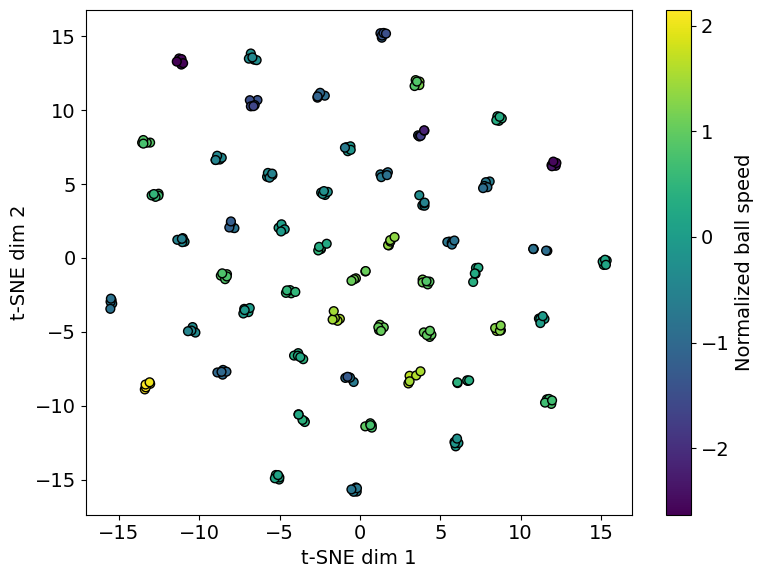

In [ ]:
# Check whether each pitcher can be separated in the t-SNE plot.
def visualize_latents(z_all, y_all):
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 14,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
    })

    z_np = np.array(z_all)
    y_np = np.array(y_all)

    reducer = TSNE(n_components=2, random_state=20, perplexity=30)
    z_2d = reducer.fit_transform(z_np)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y_np, cmap='viridis', s=40, edgecolor='k')
    plt.colorbar(sc, label='Normalized ball speed')
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.tight_layout()
    plt.savefig("./data/results/figures/tSNE_plot.pdf", dpi=300, bbox_inches='tight')
    plt.show()

z_all, y_all = extract_latents(VAE_model, train_data, device=device)
visualize_latents(z_all, y_all)

In [ ]:
# Evaluate the re-construction error of each joint
all_rmse = []
framewise_errors = []
for data in test_data:
    ori_x = data.x
    recon_x, _, _ = VAE_model(data.x.unsqueeze(0).to(device))

    recon_x = recon_x.detach().cpu()
    ori_x = ori_x.detach().cpu()

    recon_x = recon_x * sigma_pos + mu_pos
    ori_x = ori_x * sigma_pos + mu_pos

    dist_x = recon_x - ori_x
    l2 = torch.norm(dist_x, dim=2)
    rmse_per_joint = torch.sqrt(torch.mean(l2 ** 2, dim=0))

    all_rmse.append(rmse_per_joint)

all_rmse_tensor = torch.stack(all_rmse)
all_rmse_tensor = all_rmse_tensor.view(51, 5, 15)
mean_rmse_per_person = all_rmse_tensor.mean(dim=1)

#Dim0:Head, 1:RSH, 2:LSH, 3:REL, 4:LEL, 5:RWR, 6:LWR, 7:RHIP, 8:LHIP, 9:RKN, 10:LKN, 11:RHEEL, 12:LHEEL, 13:RTOE, 14:LTOE
print(mean_rmse_per_person.mean(dim=0))
print(mean_rmse_per_person.std(dim=0))

#calculate mean re-construction error (mm)
print((mean_rmse_per_person.mean(dim=0)).mean(dim=0))


/tmp/ipython-input-1151988911.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  recon_x = recon_x * sigma_pos + mu_pos
/tmp/ipython-input-1151988911.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ori_x = ori_x * sigma_pos + mu_pos


tensor([31.0037, 26.5899, 26.5020, 41.8257, 35.4808, 54.9112, 46.5761, 22.5817,
        21.5011, 22.9565, 36.9549, 20.2103, 41.0994, 17.7134, 47.9999],
       dtype=torch.float64)
tensor([ 6.4507,  4.4582,  5.4673,  9.2344,  4.9582, 10.6416,  6.8574,  4.5000,
         4.0878,  5.8096,  7.6245,  3.8403,  7.2113,  3.8073,  8.8496],
       dtype=torch.float64)
tensor(32.9271, dtype=torch.float64)


In [ ]:
# Generate comparison images of original and reconstructed motions for all pitchers
# Parameters
num_pitchers = 51
num_frames_to_plot = 10
y_delta = 750

for pitcher_ID in range(num_pitchers):

    x = train_data[pitcher_ID * 5].x.unsqueeze(0).to(device)
    recon_x, mu, logvar = VAE_model(x)

    original_pose = x[0].cpu().detach().numpy() * sigma_pos + mu_pos
    recon_pose = recon_x.cpu().detach().numpy() * sigma_pos + mu_pos

    # Plot original (top) and reconstructed (bottom)
    fig, axes = plt.subplots(2, 1, figsize=(num_frames_to_plot * 2, 12))

    for idx, (pose_seq, ax) in enumerate(zip([original_pose, recon_pose], axes)):
        frame_indices = np.linspace(0, pose_seq.shape[0] - 1, num_frames_to_plot, dtype=int)

        for i, frame_idx in enumerate(frame_indices):
            joints = pose_seq[frame_idx].copy()
            joints[:, 1] += i * y_delta

            for start, end in edge_index.T:
                y = [joints[start, 1], joints[end, 1]]
                z = [joints[start, 2], joints[end, 2]]
                ax.plot(y, z, c='black')

            ax.scatter(joints[:, 1], joints[:, 2], c='black', s=100)

        ax.set_xlabel('Y')
        ax.set_ylabel('Z')
        ax.axis('equal')
        ax.set_title("Original Motion" if idx == 0 else "Reconstructed Motion")

    plt.tight_layout()

    save_path = f"./data/results/figures/reconst_motion_figs/{pitcher_ID:03d}.pdf"
    plt.savefig(save_path, dpi=300)
    plt.close()


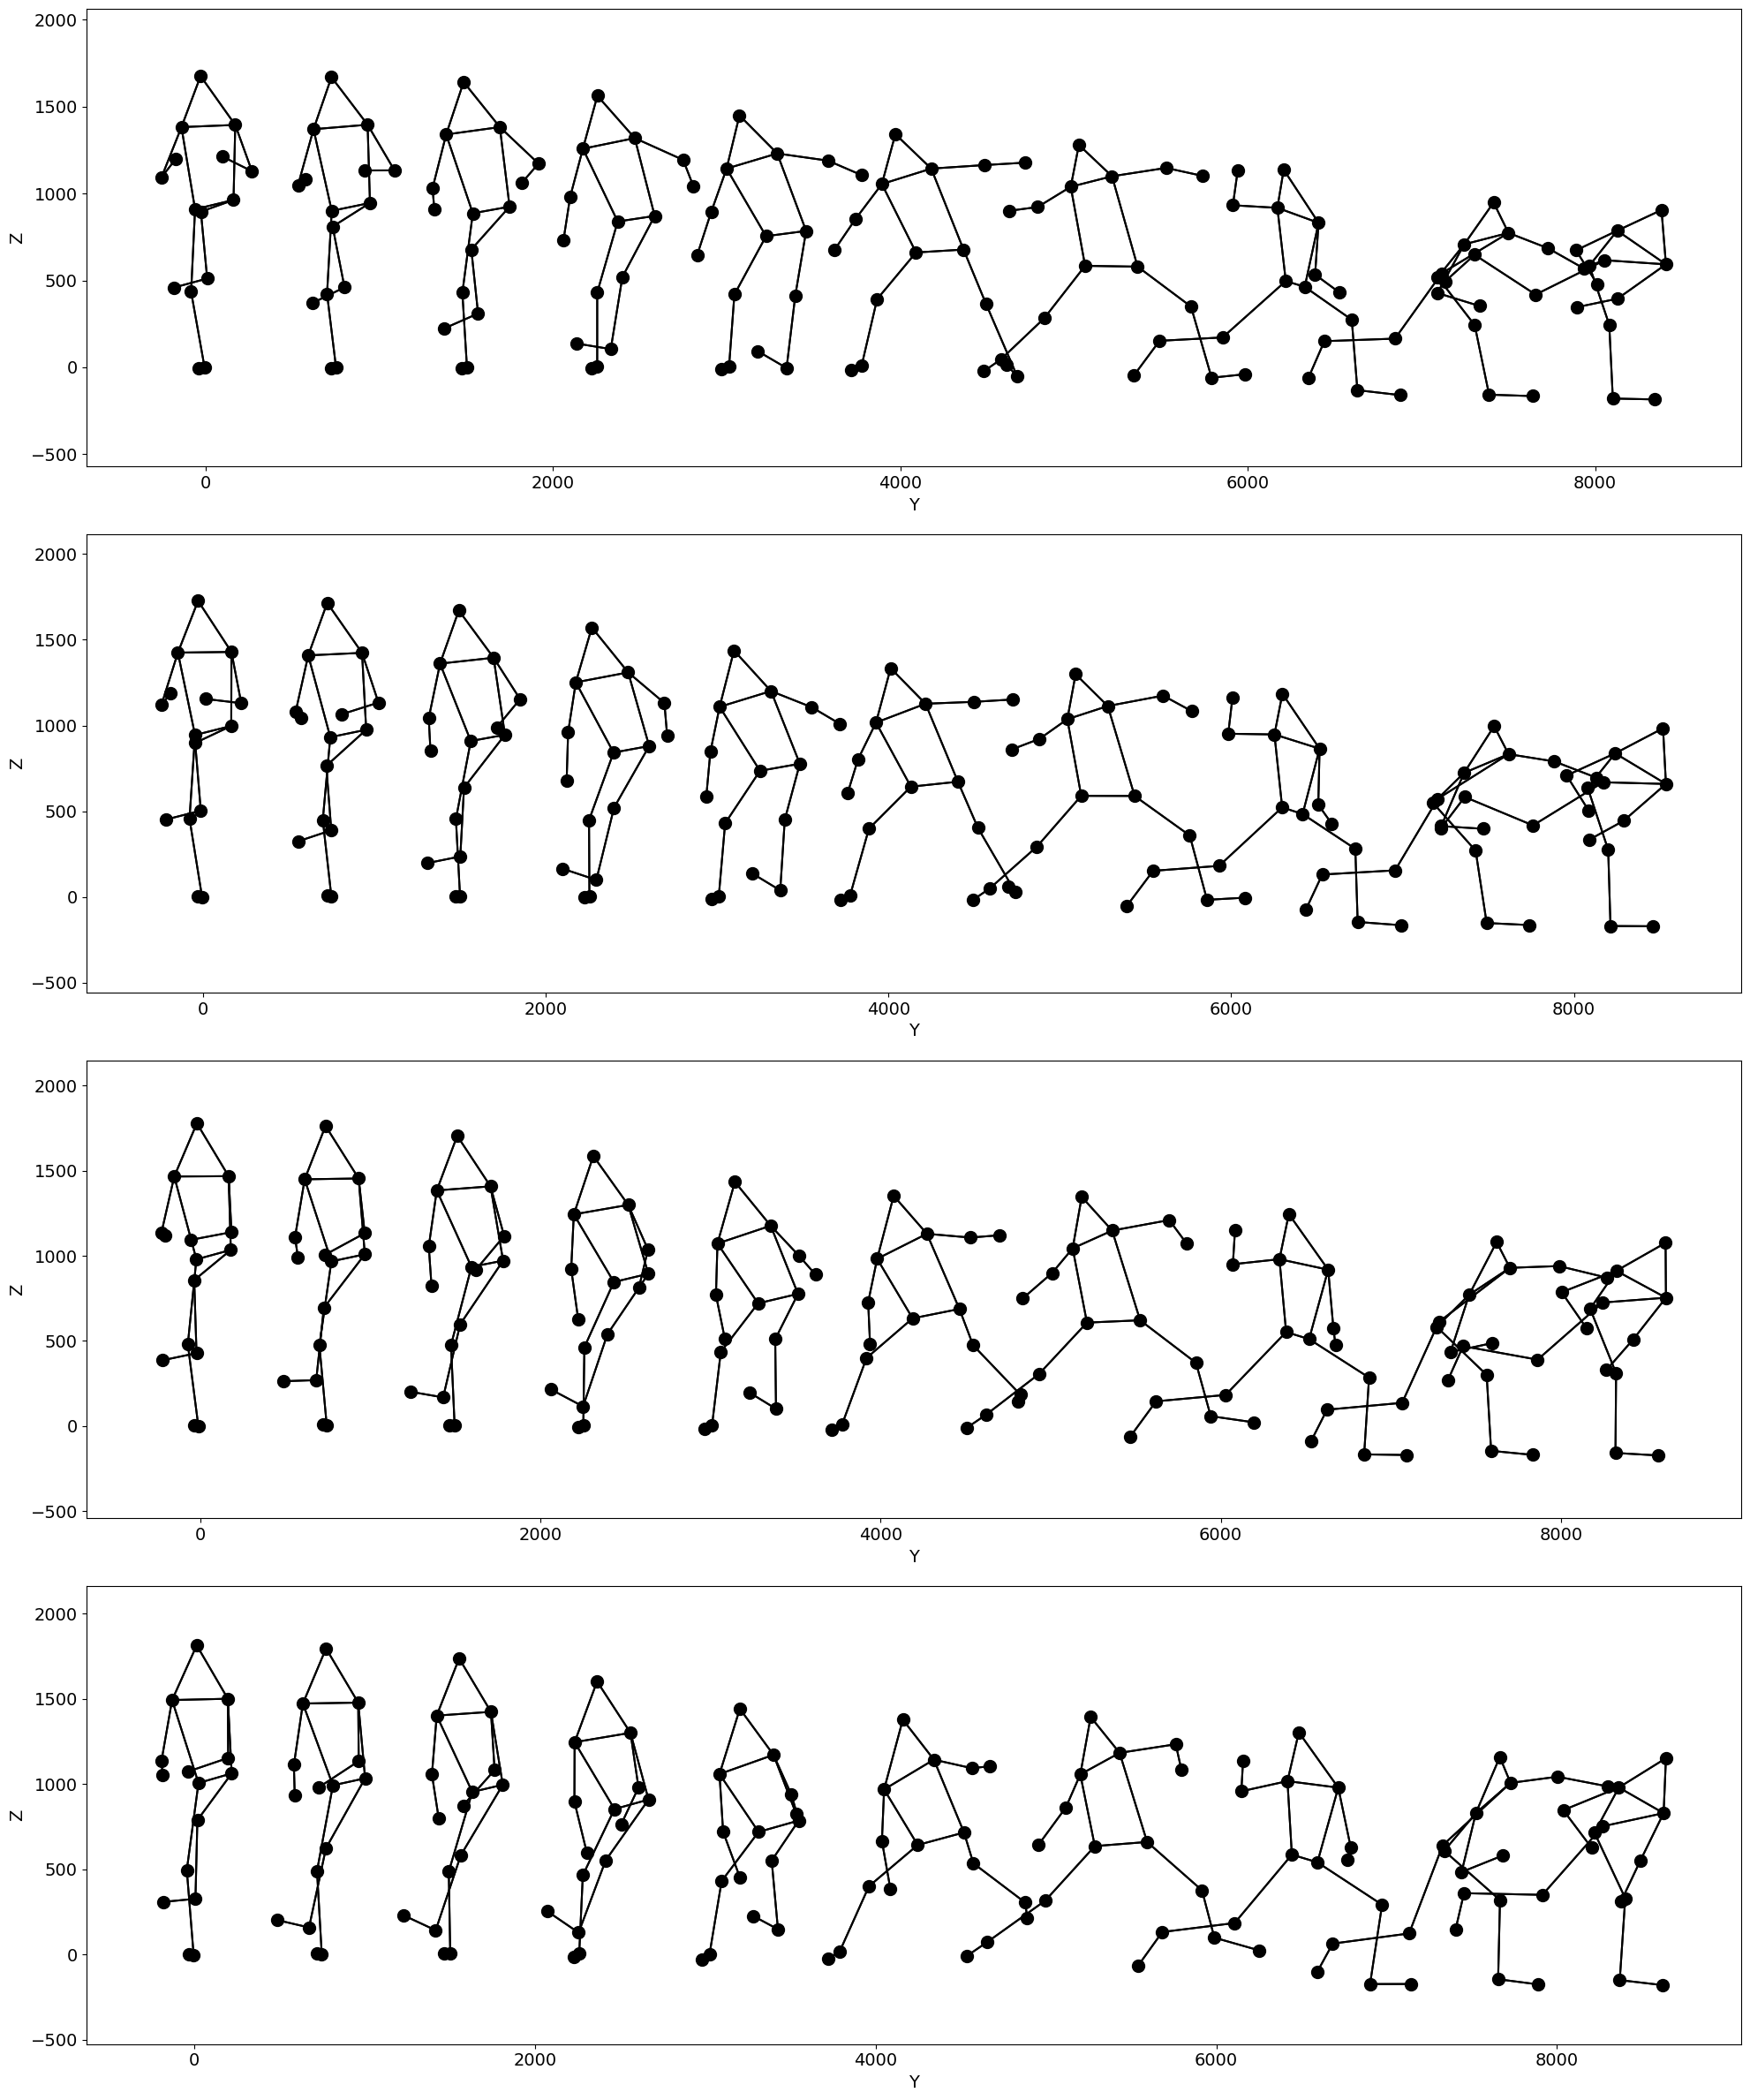

In [ ]:
# Analysis 1
# Example of the motion style transform (single pair)
# Assigne pitcher ID (0-50)
original_pitcher_ID=3
target_pitcher_ID=20

x1 = train_data[original_pitcher_ID*5].x.unsqueeze(0).to(device)
x2 = train_data[target_pitcher_ID*5].x.unsqueeze(0).to(device)

recon_x1, mu1, logvar1 = VAE_model(x1)
z1 = mu1[0].detach().clone()

recon_x2, mu2, logvar2 = VAE_model(x2)
z2 = mu2[0].detach().clone()

num_steps = 4
alphas = torch.linspace(0, 1.0, num_steps)

interpolated_poses = []

#Transform the motion from the original to the target.
for alpha in alphas:
    z_interp = (1 - alpha) * z1 + alpha * z2
    pose = VAE_model.decoder(z_interp.unsqueeze(0)).cpu().detach()
    interpolated_poses.append(pose[0].numpy())

for i, pose_seq in enumerate(interpolated_poses):
    pose_seq = pose_seq * sigma_pos + mu_pos
    pose_seq_reshape=pose_seq.reshape(101, 45)
    np.savetxt(f"./data/results/style_transformed_motions/interpolated_pose_{i}.csv", pose_seq_reshape, delimiter=",")

# Check the stick pictures of the generated motions
num_sequences = len(interpolated_poses)
num_frames_to_plot = 10
y_delta = 750

fig, axes = plt.subplots(num_sequences, 1, figsize=(num_frames_to_plot * 2, num_sequences * 6))
if num_sequences == 1:
    axes = [axes]

for seq_idx, (pose_seq, ax) in enumerate(zip(interpolated_poses, axes)):
    pose_seq = pose_seq * sigma_pos + mu_pos
    frame_indices = np.linspace(0, pose_seq.shape[0] - 1, num_frames_to_plot, dtype=int)

    for i, frame_idx in enumerate(frame_indices):
        joints = pose_seq[frame_idx].copy()
        joints[:, 1] += i * y_delta

        for start, end in edge_index.T:
            y = [joints[start, 1], joints[end, 1]]
            z = [joints[start, 2], joints[end, 2]]
            ax.plot(y, z, c='black')

        ax.scatter(joints[:, 1], joints[:, 2], c='black', s=100) #s=30, c='black'

    ax.set_xlabel('Y')
    ax.set_ylabel('Z')
    ax.axis('equal')

plt.tight_layout()

plt.savefig("./data/results/figures/style_transform_example.pdf", dpi=300)
plt.show()

In [ ]:
# Repeated transition from low-velocity to high-velocity pitcher group

# Extract the top and bottom 17 pitchers based on pitch velocity
pitcher_ids = list(range(51))
velocities = [train_data[p_id * 5].y.item() for p_id in pitcher_ids]  # Get velocity from .y

# Sort by velocity
sorted_ids = sorted(zip(pitcher_ids, velocities), key=lambda x: x[1])
low_vel_ids = [pid for pid, _ in sorted_ids[:17]]    # Bottom 17
high_vel_ids = [pid for pid, _ in sorted_ids[-17:]]  # Top 17

# Generate random pairs: (low-velocity ID, high-velocity ID) ===
random.seed(0)
pairs = list(zip(random.sample(low_vel_ids, 17), random.sample(high_vel_ids, 17)))

# Perform style transformation for each pair ===
num_steps = 4  # Number of interpolation steps
alphas = torch.linspace(0, 1.0, num_steps)

for original_pitcher_ID, target_pitcher_ID in pairs:
    x1 = train_data[original_pitcher_ID * 5].x.unsqueeze(0).to(device)
    x2 = train_data[target_pitcher_ID * 5].x.unsqueeze(0).to(device)

    recon_x1, mu1, logvar1 = VAE_model(x1)
    z1 = mu1[0].detach().clone()
    recon_x2, mu2, logvar2 = VAE_model(x2)
    z2 = mu2[0].detach().clone()

    interpolated_poses = []

    for alpha in alphas:
        z_interp = (1 - alpha) * z1 + alpha * z2
        pose = VAE_model.decoder(z_interp.unsqueeze(0)).cpu().detach()
        interpolated_poses.append(pose[0].numpy())

    num_sequences = len(interpolated_poses)
    num_frames_to_plot = 10
    y_delta = 750

    fig, axes = plt.subplots(num_sequences, 1, figsize=(num_frames_to_plot * 2, num_sequences * 6))
    if num_sequences == 1:
        axes = [axes]

    for seq_idx, (pose_seq, ax) in enumerate(zip(interpolated_poses, axes)):
        pose_seq = pose_seq * sigma_pos + mu_pos
        frame_indices = np.linspace(0, pose_seq.shape[0] - 1, num_frames_to_plot, dtype=int)

        for i, frame_idx in enumerate(frame_indices):
            joints = pose_seq[frame_idx].reshape(-1, 3).copy()
            joints[:, 1] += i * y_delta

            for start, end in edge_index.T:
                y = [joints[start, 1], joints[end, 1]]
                z = [joints[start, 2], joints[end, 2]]
                ax.plot(y, z, c='black')

            ax.scatter(joints[:, 1], joints[:, 2], c='black', s=100)

        ax.set_xlabel('Y')
        ax.set_ylabel('Z')
        ax.axis('equal')

    save_path = f"./data/results/figures/style_transform_figs/From{original_pitcher_ID}_To{target_pitcher_ID}.pdf"
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()


In [ ]:
#DTW calculation (running time: 5-6 h with T4 GPU)
re_calculation=0
mu_pos = mu_pos.reshape(15, 3)
sigma_pos = sigma_pos.reshape(15, 3)

if re_calculation==1:
  dtw_dists_to_x1_all = []
  dtw_dists_to_x2_all = []
  for ori_player in range(num_pitchers):
    print(ori_player)
    x1 = train_data[ori_player*5].x.unsqueeze(0).to(device)
    ref1 = x1[0].cpu().detach().numpy()
    ref1 = ref1 * sigma_pos + mu_pos

    traget_players = [traget_players for traget_players in range(num_pitchers) if traget_players != ori_player]
    for target_player in range(ori_player + 1, num_pitchers):
        x2 = train_data[target_player*5].x.unsqueeze(0).to(device)
        ref2 = x2[0].cpu().detach().numpy()
        ref2 = ref2 * sigma_pos + mu_pos

        dtw_dists_to_x1 = []
        dtw_dists_to_x2 = []

        J, D = ref1.shape[1], ref1.shape[2]

        recon_x1, mu1, logvar1 = VAE_model(x1)
        z1 = mu1[0].detach().clone()

        recon_x2, mu2, logvar2 = VAE_model(x2)
        z2 = mu2[0].detach().clone()

        num_steps = 10
        alphas = torch.linspace(0, 1.0, num_steps)

        interpolated_poses = []
        for alpha in alphas:
            z_interp = (1-alpha)*z1 + alpha*z2
            pose = VAE_model.decoder(z_interp.unsqueeze(0)).cpu().detach()
            pose = pose * sigma_pos + mu_pos
            interpolated_poses.append(pose[0].numpy())

        J, D = ref1.shape[1], ref1.shape[2]

        dtw_dists_to_x1 = []
        dtw_dists_to_x2 = []
        for pose in interpolated_poses:
            total_dist1 = 0.0
            total_dist2 = 0.0

            for j in range(J):
                for d in range(D):
                    s_interp = pose[:, j, d]
                    s_ref1 = ref1[:, j, d]
                    s_ref2 = ref2[:, j, d]

                    dist1 = dtw.distance(s_interp, s_ref1)
                    dist2 = dtw.distance(s_interp, s_ref2)

                    total_dist1 += dist1
                    total_dist2 += dist2

            dtw_dists_to_x1.append(total_dist1)
            dtw_dists_to_x2.append(total_dist2)

        dtw_dists_to_x1 = [x / (101*45) for x in dtw_dists_to_x1]
        dtw_dists_to_x2 = [x / (101*45) for x in dtw_dists_to_x2]

        dtw_dists_to_x1_all.append(dtw_dists_to_x1)
        dtw_dists_to_x2_all.append(dtw_dists_to_x2)

  x1_dtw=np.array(dtw_dists_to_x1_all)
  x2_dtw=np.array(dtw_dists_to_x2_all)
  np.save("./data/results/dtw_dists/dtw_dists_to_x1_all.npy", x1_dtw)
  np.save("./data/results/dtw_dists/dtw_dists_to_x2_all.npy", x2_dtw)
else:
  x1_dtw = np.load("./data/results/dtw_dists/dtw_dists_to_x1_all.npy")
  x2_dtw = np.load("./data/results/dtw_dists/dtw_dists_to_x2_all.npy")

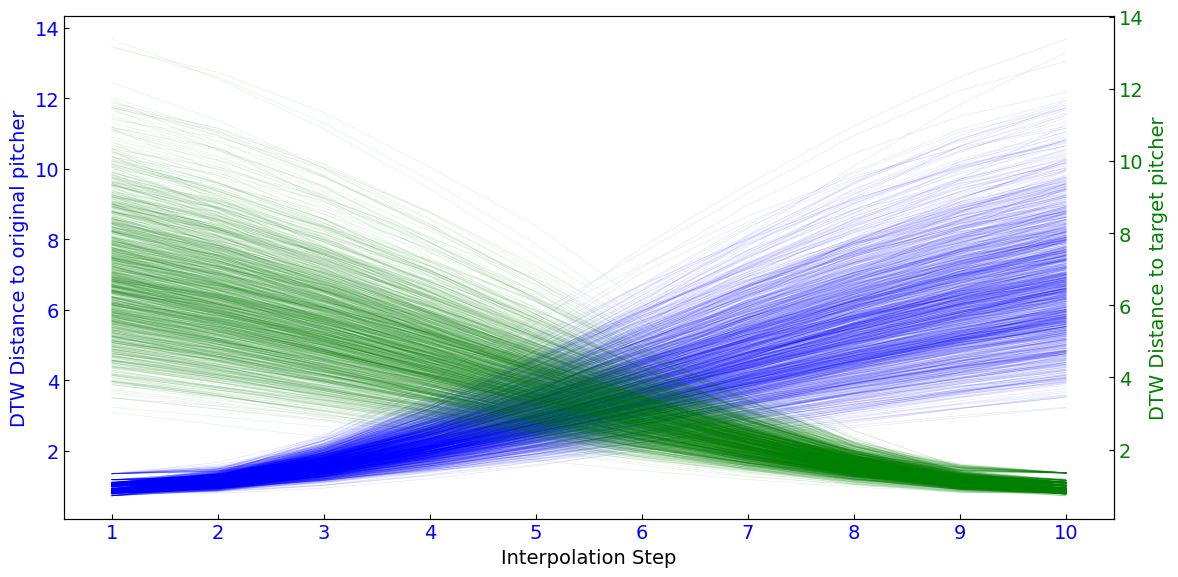

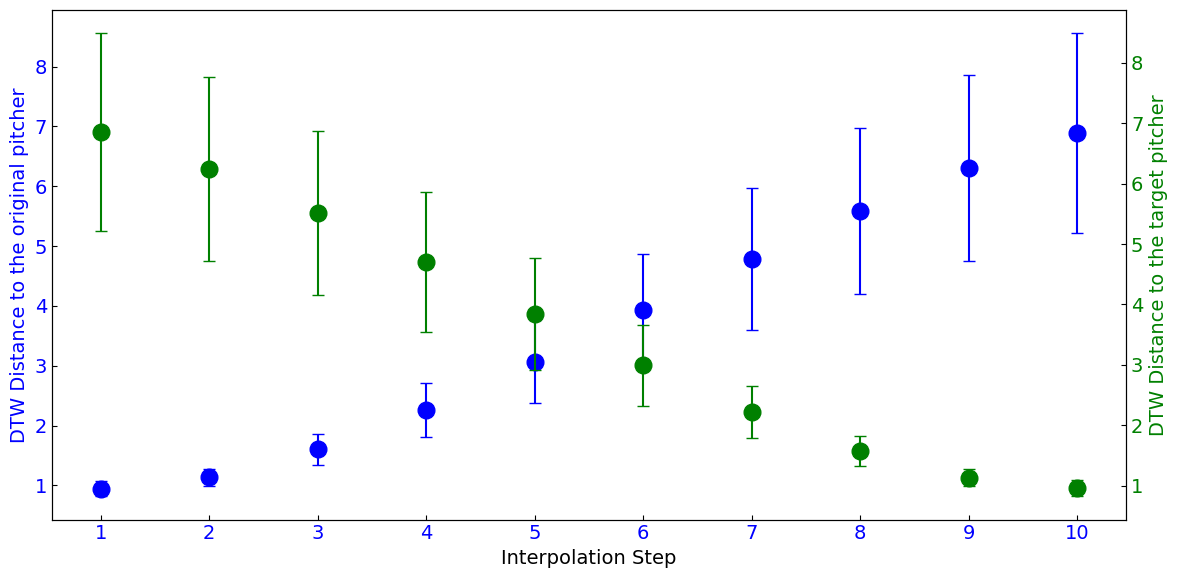

In [ ]:
# Plot and check the results of DTW analysis
# 1. Individual plots of all data
num_steps = x1_dtw.shape[1]
steps = np.arange(1, num_steps + 1)

plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

# === Plot individual DTW sequences ===
fig, ax1 = plt.subplots(figsize=(12, 6))

for row in x1_dtw:
    ax1.plot(steps, row, color='blue', alpha=0.1, linewidth=0.5)
ax1.set_ylabel('DTW Distance to original pitcher', color='blue')
ax1.tick_params(axis='both', labelcolor='blue', direction='in')

ax2 = ax1.twinx()
for row in x2_dtw:
    ax2.plot(steps, row, color='green', alpha=0.1, linewidth=0.5)
ax2.set_ylabel('DTW Distance to target pitcher', color='green')
ax2.tick_params(axis='both', labelcolor='green', direction='in')

ax1.set_xlabel("Interpolation Step")
ax1.set_xticks(steps)
ax1.set_xticklabels([str(s) for s in steps])

plt.tight_layout()
plt.savefig("./data/results/figures/dtw_all_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()

# 2. Plot of the mean and standard deviation
mean_x1 = x1_dtw.mean(axis=0)
std_x1 = x1_dtw.std(axis=0)

mean_x2 = x2_dtw.mean(axis=0)
std_x2 = x2_dtw.std(axis=0)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot mean ± std for x1
ax1.errorbar(
    steps, mean_x1, yerr=std_x1,
    fmt='o', color='blue', ecolor='blue',
    elinewidth=1.5, capsize=4, markerfacecolor='blue', markeredgecolor='blue',
    markersize=12,
    label='x1 DTW ± std'
)
ax1.set_ylabel("DTW Distance to the original pitcher", color='blue')
ax1.tick_params(axis='both', labelcolor='blue', direction='in')

# Secondary axis for x2
ax2 = ax1.twinx()
ax2.errorbar(
    steps, mean_x2, yerr=std_x2,
    fmt='o', color='green', ecolor='green',
    elinewidth=1.5, capsize=4, markerfacecolor='green', markeredgecolor='green',
    markersize=12,
    label='x2 DTW ± std'
)
ax2.set_ylabel("DTW Distance to the target pitcher", color='green')
ax2.tick_params(axis='both', labelcolor='green', direction='in')

#ax1.spines['top'].set_visible(False)
#ax2.spines['top'].set_visible(False)

ax1.set_xlabel("Interpolation Step")
ax1.set_xticks(steps)
ax1.set_xticklabels([str(s) for s in steps])

plt.tight_layout()
plt.savefig("./data/results/figures/dtw_error_bar_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
#Functions for the Analysis 2
EFFECT_SIGN = np.array([-1, 1, 1, 1, 1, 1, 1, 1], dtype=np.float64)
J = 15
HEAD  = 1;R_SHO = 2;L_SHO = 3
R_ELB = 4;L_ELB = 5;R_WR  = 6
L_WR  = 7;R_HIP = 8;L_HIP = 9
R_KNE = 10;L_KNE = 11;R_ANK = 12;L_ANK = 13

def decode_with_mu(VAE_model, x_input):
    VAE_model.eval()
    with torch.no_grad():
        mu, _ = VAE_model.encode(x_input)               # mu: (B, latent_dim)
        recon = VAE_model.decoder(mu, T=x_input.size(1))  # (B, T, 15, 3)
    return recon

def _encode_to_flat_z(model, x_1xTxJxD: torch.Tensor):
    model.eval()
    with torch.no_grad():
        mu, _ = model.encode(x_1xTxJxD)  # mu: (1, latent_dim)
    z_vec = mu.detach().cpu().numpy().reshape(-1)  # -> (latent_dim,)
    return z_vec, None


def _decode_from_flat_z(model, device, z_vec_np: np.ndarray, T: int, aux=None):
    model.eval()
    z = torch.from_numpy(z_vec_np[None, :]).to(device=device, dtype=torch.float32)  # (1, latent_dim)
    with torch.no_grad():
        recon = model.decoder(z, T=T)[0].detach().cpu().numpy()  # (T, 15, 3)
    return recon

def _to_45(x):
    arr = np.asarray(x)
    if arr.shape == (45,):
       return arr
    if arr.shape == (15, 3):
       return arr.reshape(-1)

def _jxyz(motion: np.ndarray, j_idx1: int) -> np.ndarray:
    j0 = (j_idx1 - 1) * 3
    return motion[:, j0:j0+3]

def _safe_norm(x: np.ndarray, axis: int = -1, keepdims: bool = False, eps: float = 1e-8) -> np.ndarray:
    n = np.linalg.norm(x, axis=axis, keepdims=keepdims)
    return np.maximum(n, eps)

def _unit(x: np.ndarray, axis: int = -1, eps: float = 1e-8) -> np.ndarray:
    return x / _safe_norm(x, axis=axis, keepdims=True, eps=eps)

def _acos_clamped(cos_theta: np.ndarray) -> np.ndarray:
    return np.arccos(np.clip(cos_theta, -1.0, 1.0))

def _vel_mag(traj_xyz: np.ndarray) -> np.ndarray:
    v = np.diff(traj_xyz, axis=0)
    return _safe_norm(v, axis=1)

def _idx_range_ending_at(t_end: int, length: int, T: int) -> Tuple[int, int]:
    t_end = int(np.clip(t_end, 1, T-1))
    t_start = max(0, t_end - (length - 1))
    return t_start, t_end

def release_time_original(motion: np.ndarray) -> int:
    wr = _jxyz(motion, R_WR)
    v = _vel_mag(wr)
    t = int(np.argmax(v)) + 1
    return t

def release_time_reconst(motion_re: np.ndarray, motion_ori: np.ndarray, t_rel_ori: int) -> int:
    target_pose = motion_ori[t_rel_ori, :]
    diff = motion_re - target_pose[None, :]
    d = _safe_norm(diff.reshape(diff.shape[0], -1), axis=1)
    t = int(np.argmin(d))
    return t

def inverse_standardize(flat_pose_Tx45, mu_pos, sigma_pos, eps=1e-8):
    mu = _to_45(mu_pos).astype(np.float64)
    std = _to_45(sigma_pos).astype(np.float64)
    std = np.where(np.abs(std) < eps, 1.0, std)
    return flat_pose_Tx45 * std[None, :] + mu[None, :]

def apply_lowpass_filter(data, cutoff=10, fs=83, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = filtfilt(b, a, data, axis=0)
    return filtered_data

def _features_vec_from_pair(ori_denorm: np.ndarray, re_denorm: np.ndarray):
    f_ori, f_re = compute_features_for_pitch(ori_denorm, re_denorm)
    v_ori = np.array([
        f_ori.SJM, f_ori.shoulder_abd, f_ori.trunk_forward_tilt, f_ori.trunk_lateral_tilt,
        f_ori.peak_hip_rot_velo, f_ori.dt_peak_shoulder_vs_hip, f_ori.lead_knee_flex, f_ori.stride_length
    ], dtype=np.float64)
    v_re = np.array([
        f_re.SJM, f_re.shoulder_abd, f_re.trunk_forward_tilt, f_re.trunk_lateral_tilt,
        f_re.peak_hip_rot_velo, f_re.dt_peak_shoulder_vs_hip, f_re.lead_knee_flex, f_re.stride_length
    ], dtype=np.float64)
    return v_ori, v_re

def _combine_balanced(g, method="sum", alpha=5.0, eps=1e-6):
    if method == "sum":
        return float(np.sum(g))
    if method == "softmin":
        val = - (1.0 / alpha) * np.log(np.sum(np.exp(-alpha * g)))
        return float(val)
    if method == "nash":
        gp = np.maximum(g, 0.0)
        val = float(np.sum(np.log(gp + eps)))
        return val
    if method == "harmonic":
        gp = np.maximum(g, 0.0)
        denom = np.sum(1.0 / (gp + eps))
        k = g.shape[0]
        val = float(k / denom)
        return val
    raise ValueError(f"Unknown combine method: {method}")

@dataclass
class Features:
    SJM: float
    shoulder_abd: float
    trunk_forward_tilt: float
    trunk_lateral_tilt: float
    peak_hip_rot_velo: float
    dt_peak_shoulder_vs_hip: float
    lead_knee_flex: float
    stride_length: float

def compute_features_for_pitch(motion_ori, motion_re):
    T = motion_ori.shape[0]
    t_rel_ori = release_time_original(motion_ori)
    t_rel_re  = release_time_reconst(motion_re, motion_ori, t_rel_ori)


    def win17_end_at(t_end):
        s, e = _idx_range_ending_at(t_end, length=17, T=T)
        return s, e

    # 1. Shoulder-joint movement (SJM)
    lsho_ori = _jxyz(motion_ori, L_SHO)
    lsho_re  = _jxyz(motion_re,  L_SHO)
    v_lsho_ori = _vel_mag(lsho_ori)
    v_lsho_re  = _vel_mag(lsho_re)

    s1o, e1o = win17_end_at(t_rel_ori)
    s1r, e1r = win17_end_at(t_rel_re)

    SJM_ori = float(np.sum(v_lsho_ori[s1o:e1o]))
    SJM_re  = float(np.sum(v_lsho_re [s1r:e1r]))

    # 2. Shoulder abduction
    def shoulder_abd(motion, t_end):
        s, e = win17_end_at(t_end)
        rhip = _jxyz(motion, R_HIP)[s:e+1]
        rsho = _jxyz(motion, R_SHO)[s:e+1]
        rel  = _jxyz(motion, R_ELB)[s:e+1]
        v1 = _unit(rhip - rsho, axis=1)
        v2 = _unit(rel  - rsho, axis=1)
        cos_t = np.sum(v1*v2, axis=1)
        theta = _acos_clamped(cos_t)
        return np.mean(theta)

    shoulder_abd_ori = shoulder_abd(motion_ori, t_rel_ori)
    shoulder_abd_re  = shoulder_abd(motion_re,  t_rel_re)

    # 3. Forward-trunk-tilt at release
    def trunk_forward_tilt(motion, t_rel):
        hip_center = 0.5 * (_jxyz(motion, R_HIP)[t_rel] + _jxyz(motion, L_HIP)[t_rel])
        sho_center = 0.5 * (_jxyz(motion, R_SHO)[t_rel] + _jxyz(motion, L_SHO)[t_rel])
        vec = sho_center - hip_center
        vec_yz = np.array([vec[1], vec[2]])
        vec_yz = vec_yz / _safe_norm(vec_yz, axis=0)
        ref = np.array([1.0, 0.0])
        cos_t = float(np.dot(ref, vec_yz))
        return float(_acos_clamped(cos_t))

    trunk_f_ori = trunk_forward_tilt(motion_ori, t_rel_ori)
    trunk_f_re  = trunk_forward_tilt(motion_re,  t_rel_re)

    # 4. Lateral-trunk-tilt at release
    def trunk_lateral_tilt(motion, t_rel):
        head = _jxyz(motion, HEAD)[t_rel]
        lheel = _jxyz(motion, L_ANK)[t_rel]
        vec = head - lheel
        vec_xz = np.array([vec[0], vec[2]])
        vec_xz = vec_xz / _safe_norm(vec_xz, axis=0)
        ref = np.array([0.0, 1.0])
        cos_t = float(np.dot(vec_xz, ref))
        return float(_acos_clamped(cos_t))

    trunk_l_ori = trunk_lateral_tilt(motion_ori, t_rel_ori)
    trunk_l_re  = trunk_lateral_tilt(motion_re,  t_rel_re)

    #5. peak hip rotational velocity
    def peak_hip_rot_velo(motion, t_rel):
        rhip = _jxyz(motion, R_HIP)[:t_rel+1, :2]
        lhip = _jxyz(motion, L_HIP)[:t_rel+1, :2]
        v = _unit(rhip - lhip, axis=1)
        ang = np.arctan2(v[:, 1], v[:, 0])
        ang = np.unwrap(ang)
        d_ang = np.abs(np.diff(ang))
        t = int(np.argmax(d_ang)) + 1
        return float(np.max(d_ang)), t

    peak_hip_ori, t_hip_ori = peak_hip_rot_velo(motion_ori, t_rel_ori)
    peak_hip_re,  t_hip_re  = peak_hip_rot_velo(motion_re,  t_rel_re)

    # 6. Hip-shoulder separation
    def peak_shoulder_time(motion, t_rel):
        rsh = _jxyz(motion, R_SHO)[:t_rel+1, :2]
        lsh = _jxyz(motion, L_SHO)[:t_rel+1, :2]
        v = _unit(rsh - lsh, axis=1)
        ang = np.arctan2(v[:, 1], v[:, 0])
        ang = np.unwrap(ang)
        d_ang = np.abs(np.diff(ang))
        t = int(np.argmax(d_ang)) + 1
        return float(np.max(d_ang)), t

    _, t_sh_ori = peak_shoulder_time(motion_ori, t_rel_ori)
    _, t_sh_re  = peak_shoulder_time(motion_re,  t_rel_re)
    dt_sh_vs_hip_ori = float(t_sh_ori - t_hip_ori)
    dt_sh_vs_hip_re  = float(t_sh_re  - t_hip_re)

    # 7. Lead knee flexio
    def lead_knee_flex(motion, t_rel):
        lhip  = _jxyz(motion, L_HIP)[t_rel]
        lknee = _jxyz(motion, L_KNE)[t_rel]
        lheel = _jxyz(motion, L_ANK)[t_rel]
        v1 = _unit(lhip  - lknee)
        v2 = _unit(lheel - lknee)
        cos_t = float(np.dot(v1, v2))
        return float(_acos_clamped(cos_t))

    knee_flex_ori = lead_knee_flex(motion_ori, t_rel_ori)
    knee_flex_re  = lead_knee_flex(motion_re,  t_rel_re)

    # 8. Stride-length
    def stride_length(motion, t_rel):
        lheel_y = _jxyz(motion, L_ANK)[t_rel, 1]
        rankle_y0 = _jxyz(motion, R_ANK)[0, 1]
        return float(lheel_y - rankle_y0)

    stride_ori = stride_length(motion_ori, t_rel_ori)
    stride_re  = stride_length(motion_re,  t_rel_re)

    f_ori = Features(
        SJM=SJM_ori, shoulder_abd=shoulder_abd_ori,
        trunk_forward_tilt=trunk_f_ori, trunk_lateral_tilt=trunk_l_ori,
        peak_hip_rot_velo=peak_hip_ori, dt_peak_shoulder_vs_hip=dt_sh_vs_hip_ori,
        lead_knee_flex=knee_flex_ori, stride_length=stride_ori)

    f_re = Features(
        SJM=SJM_re, shoulder_abd=shoulder_abd_re,
        trunk_forward_tilt=trunk_f_re, trunk_lateral_tilt=trunk_l_re,
        peak_hip_rot_velo=peak_hip_re, dt_peak_shoulder_vs_hip=dt_sh_vs_hip_re,
        lead_knee_flex=knee_flex_re, stride_length=stride_re)
    return f_ori, f_re

def objective_feature_change_score(VAE_model, device, player_pitches, u, r, mu_pos, sigma_pos,
    eps_scale=1e-6, clip=None, weights=None, combine="nash", softmin_alpha=5.0, hip_shoulder_scale=10.0):
    feats_ori = []
    feats_re  = []
    for d in player_pitches:
        x_input = d.x.unsqueeze(0).to(device).view(1, 101, 15, 3)
        _, T, _, _ = x_input.shape

        mu, _ = VAE_model.encode(x_input)
        z0_np = mu.detach().cpu().numpy().reshape(-1)
        z_prime = z0_np + r * u

        ori = x_input[0].detach().cpu().numpy().reshape(T, -1)
        ori_denorm = inverse_standardize(ori, mu_pos, sigma_pos)
        ori_denorm = apply_lowpass_filter(ori_denorm)

        z_temp = torch.from_numpy(z_prime[None, :]).to(device=device, dtype=torch.float32)  # (1,D)
        recon = VAE_model.decoder(z_temp, T=T)[0].detach().cpu().numpy()

        re_denorm = inverse_standardize(recon.reshape(T, -1), mu_pos, sigma_pos)
        re_denorm = apply_lowpass_filter(re_denorm)

        v_ori, v_re = _features_vec_from_pair(ori_denorm, re_denorm)  # (8,)
        feats_ori.append(v_ori)
        feats_re.append(v_re)

    A = np.asarray(feats_ori, dtype=np.float64)
    B = np.asarray(feats_re,  dtype=np.float64)

    non_angle_idx     = np.array([0, 4, 7])
    hip_shoulder_idx  = 5
    angle_idx         = np.array([1, 2, 3, 6])

    med_abs_A = np.median(np.abs(A), axis=0)
    eps = eps_scale * np.maximum(1.0, med_abs_A)

    delta = np.zeros_like(A)

    if non_angle_idx.size > 0:
        ori_sub = A[:, non_angle_idx]
        re_sub  = B[:, non_angle_idx]
        eps_non = eps[non_angle_idx][None, :]
        denom = np.sign(ori_sub) * np.maximum(np.abs(ori_sub), eps_non)
        delta[:, non_angle_idx] = (re_sub - ori_sub) / denom

    if angle_idx.size > 0:
        ori_sub = A[:, angle_idx]
        re_sub  = B[:, angle_idx]
        delta[:, angle_idx] = (re_sub - ori_sub) / np.pi

    ori_hs = A[:, hip_shoulder_idx]
    re_hs  = B[:, hip_shoulder_idx]
    delta[:, hip_shoulder_idx] = (re_hs - ori_hs) / float(hip_shoulder_scale)

    if clip is not None and clip > 0:
        delta = np.clip(delta, -clip, clip)

    d_vec = delta.mean(axis=0)

    if weights is None:
        weights = np.ones(8, dtype=np.float64)

    signed_weights = EFFECT_SIGN * weights
    g = signed_weights * d_vec

    score = _combine_balanced(g, method=combine, alpha=softmin_alpha, eps=1e-6)
    return score, d_vec

def best_on_sphere_for_player_es(
    player_pitches, VAE_model, device, mu_pos, sigma_pos, weights=np.ones(8, dtype=np.float64),
    r=5.0, iters=20, popsize=128, sigma=0.3, lr=0.5, seed=0):

    rng = np.random.RandomState(seed)

    x0 = player_pitches[0].x.unsqueeze(0).to(device).view(1, 101, 15, 3)
    z0_np, _ = _encode_to_flat_z(VAE_model, x0)
    D = int(z0_np.shape[0])

    m = rng.normal(size=D)
    m /= (np.linalg.norm(m) + 1e-12)

    best_score = -1e18
    best_u = m.copy()
    per_u_scores = []

    for _ in range(iters):
        eps = rng.normal(size=(popsize//2, D))
        eps = np.concatenate([eps, -eps], axis=0)

        U = m[None, :] + sigma * eps
        U /= (np.linalg.norm(U, axis=1, keepdims=True) + 1e-12)

        scores = []
        for u in U:
            score, d_vec = objective_feature_change_score(
                VAE_model, device, player_pitches, u, r, mu_pos, sigma_pos,
                weights=weights
            )
            scores.append(score)
            per_u_scores.append(score)
            if score > best_score:
                print(d_vec); print(best_score)
                best_score = score
                best_u = u.copy()
        scores = np.asarray(scores, dtype=np.float64)

        g = (scores[:, None] * eps).mean(axis=0) / (sigma + 1e-12)
        m = m + lr * g
        m /= (np.linalg.norm(m) + 1e-12)

    z_best_per_pitch = []
    for d in player_pitches:
        x_input = d.x.unsqueeze(0).to(device).view(1, 101, 15, 3)
        z0_np, _ = _encode_to_flat_z(VAE_model, x_input)
        z_best_per_pitch.append(z0_np + r * best_u)

    return {"u_best": best_u,"score_best_avg": float(best_score),
        "z_best_per_pitch": z_best_per_pitch,"all_u_scores": np.array(per_u_scores),
        "radius": r,"dim": D}

def features_player_level(
    players_data: List[List],VAE_model,
    device,mu_pos, sigma_pos):

    all_players_ori = []
    all_players_re  = []

    for player_idx, pitches in enumerate(players_data):
        per_pitch_features_ori = []
        per_pitch_features_re  = []

        for pitch_data in pitches:
            x_input = pitch_data.x.unsqueeze(0).to(device).view(1, 101, 15, 3)
            _, T, J, D = x_input.shape

            recon = decode_with_mu(VAE_model, x_input)[0]
            motion_ori = x_input[0].detach().cpu().numpy()
            motion_re  = recon.detach().cpu().numpy()

            ori_flat   = motion_ori.reshape(T, -1)
            recon_flat = motion_re.reshape(T, -1)

            ori_denorm   = inverse_standardize(ori_flat,   mu_pos, sigma_pos)
            recon_denorm = inverse_standardize(recon_flat, mu_pos, sigma_pos)

            ori_denorm   = apply_lowpass_filter(ori_denorm)
            recon_denorm = apply_lowpass_filter(recon_denorm)

            f_ori, f_re = compute_features_for_pitch(ori_denorm, recon_denorm)
            per_pitch_features_ori.append([
                f_ori.SJM, f_ori.shoulder_abd, f_ori.trunk_forward_tilt, f_ori.trunk_lateral_tilt,
                f_ori.peak_hip_rot_velo, f_ori.dt_peak_shoulder_vs_hip, f_ori.lead_knee_flex, f_ori.stride_length
            ])
            per_pitch_features_re.append([
                f_re.SJM, f_re.shoulder_abd, f_re.trunk_forward_tilt, f_re.trunk_lateral_tilt,
                f_re.peak_hip_rot_velo, f_re.dt_peak_shoulder_vs_hip, f_re.lead_knee_flex, f_re.stride_length
            ])

        mean_ori = np.mean(np.asarray(per_pitch_features_ori, dtype=np.float64), axis=0)
        mean_re  = np.mean(np.asarray(per_pitch_features_re,  dtype=np.float64), axis=0)

        all_players_ori.append(mean_ori)
        all_players_re.append(mean_re)

    feature_values_ori = np.asarray(all_players_ori, dtype=np.float64).T
    feature_values_re  = np.asarray(all_players_re,  dtype=np.float64).T
    return feature_values_ori, feature_values_re

def build_players_data(all_data, pitches_per_player=5):
    return [all_data[i:i+pitches_per_player] for i in range(0, len(all_data), pitches_per_player)]

def filter_bottom_third_by_y(players_data, y_index=1):
    mean_y_per_player = []
    for pdata in players_data:
        ys = []
        for d in pdata:
            ys.append(d.y.cpu().numpy())
        mean_y_per_player.append(np.mean(ys))

    mean_y_per_player = np.array(mean_y_per_player)
    cutoff = int(np.ceil(len(players_data) / 3))
    sorted_indices = np.argsort(mean_y_per_player)
    target_indices = sorted_indices[:cutoff]
    filtered_players_data = [players_data[i] for i in target_indices]
    return filtered_players_data, target_indices

In [ ]:
FEATURE_NAMES = ["SJM", "shoulder_abd", "trunk_forward_tilt", "trunk_lateral_tilt",
   "peak_hip_rot_velo", "dt_peak_shoulder_vs_hip", "lead_knee_flex", "stride_length"]

players_data = build_players_data(all_data, pitches_per_player=5)
players_data, target_indices = filter_bottom_third_by_y(players_data)

r = 5.0
samples = 256
iters=20
custom_weights = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

results_per_player = []
count=1
for player_pitches in players_data:
    print(count)
    res=best_on_sphere_for_player_es(
        player_pitches, VAE_model, device, mu_pos, sigma_pos, weights=custom_weights,
        r=r, iters=iters, popsize=samples, sigma=0.1, lr=0.5, seed=0)

    results_per_player.append(res)

    count=count+1

res0 = results_per_player[0]
print("dim:", res0["dim"], "radius:", res0["radius"])
print("best avg score:", res0["score_best_avg"])

1
[-0.05774233 -0.01984389 -0.00881473  0.00049143 -0.14128493 -0.04
  0.02753678 -0.01268153]
-1e+18
[-0.08210588 -0.02531613 -0.02089205 -0.00888225 -0.16787162 -0.04
  0.02103493  0.01565355]
-83.1376635759303
[-0.06033471 -0.0201153  -0.00830054 -0.00826797 -0.1412527  -0.04
  0.01973944  0.03377074]
-79.59580322716822
[-0.06024102 -0.01590123 -0.01459778 -0.00347886 -0.15659156 -0.04
  0.04094524  0.01811809]
-79.19860111441872
[-0.06549454 -0.02252245 -0.02302155  0.00403119 -0.17546713 -0.04
  0.02693257  0.01423366]
-79.09322261557719
[-0.08477675 -0.01231786 -0.03582812  0.00358158 -0.17230561 -0.04
  0.02475308  0.02713735]
-71.36771773173939
[-0.08882303 -0.0010029   0.01326438  0.00478313 -0.14631805 -0.04
  0.0427384  -0.00381986]
-70.66700921229616
[-0.07703424  0.00120276 -0.0064741   0.00809264 -0.15625306 -0.04
  0.03305727  0.00979426]
-70.50082289174583
[-0.08586899  0.00201915 -0.00923541  0.00570219 -0.13402029 -0.04
  0.03330325  0.01752664]
-63.584347742862796
[-

In [ ]:
# Save the re-construt motion
# the following analysis was conducted on MATLAB (xxx.mat)
save_dir = "./data/results/reconstruct_motions"
os.makedirs(save_dir, exist_ok=True)

for i_player, (player_pitches, res) in enumerate(zip(players_data, results_per_player)):
    T_idx = int(target_indices[i_player])

    z_list = res["z_best_per_pitch"]

    for k_pitch, (pitch_data, z_best_np) in enumerate(zip(player_pitches, z_list), start=1):
        x_np = pitch_data.x.detach().cpu().numpy()
        T_frames = x_np.shape[0]

        recon_norm = _decode_from_flat_z(model=VAE_model,
            device=device,z_vec_np=z_best_np,
            T=T_frames,aux=None)

        recon_norm_flat = recon_norm.reshape(T_frames, -1)
        recon_denorm_flat = inverse_standardize(flat_pose_Tx45=recon_norm_flat,
            mu_pos=mu_pos,sigma_pos=sigma_pos)

        recon_denorm_flat = apply_lowpass_filter(recon_denorm_flat, cutoff=10, fs=83, order=4)

        filename = f"P{T_idx:01d}_{k_pitch:01d}.csv"
        out_path = os.path.join(save_dir, filename)
        np.savetxt(out_path.replace(".npy", ".csv"), recon_denorm_flat, delimiter=",")
        print(f"Saved: {out_path}  shape={recon_denorm_flat.shape}")


Saved: ./data/results/reconstruct_motions/P46_1.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P46_2.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P46_3.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P46_4.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P46_5.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P41_1.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P41_2.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P41_3.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P41_4.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P41_5.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P32_1.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P32_2.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P32_3.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_motions/P32_4.csv  shape=(101, 45)
Saved: ./data/results/reconstruct_

In [ ]:
# from google.colab import runtime
# runtime.unassign()